# Notebook 03 — Evaluation & Comparison

Phase 5 deliverable: three comparison studies that together answer the research question.

1. **Attribution comparison** — which model recovers ground-truth platform influence most accurately?
2. **Model comparison** — ROC curves + confusion matrices for all 6 trained classifiers.
3. **Strategy comparison** — which automation strategy (`fixed` / `trigger` / `hybrid`) wins on conversion rate and prediction accuracy?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

from src.evaluation import (
    attribution_comparison_study,
    model_comparison_study,
    strategy_comparison_study,
)

FIGS = Path('../outputs/figures')
MDLS = Path('../outputs/models')
FIGS.mkdir(parents=True, exist_ok=True)

In [2]:
events   = pd.read_csv('../data/simulated/event_logs.csv', parse_dates=['timestamp'])
gt       = pd.read_csv('../data/simulated/ground_truth_influence.csv')
features = pd.read_csv('../data/processed/features.csv')

print(f'Events  : {len(events):,} rows | {events["user_id"].nunique():,} users')
print(f'Features: {features.shape}')
print(f'Converters : {features["converted"].sum()} ({features["converted"].mean()*100:.1f}%)')
print(f'Dropped-off: {features["dropped_off"].sum()} ({features["dropped_off"].mean()*100:.1f}%)')

Events  : 56,906 rows | 10,000 users
Features: (10000, 14)
Converters : 1149 (11.5%)
Dropped-off: 6375 (63.7%)


---
## Study 1 — Attribution comparison

In [3]:
from src.attribution import compare_to_ground_truth, attribution_mae

comp = attribution_comparison_study(events, gt, FIGS)

mae = attribution_mae(comp)
mae_df = pd.DataFrame([
    {'Model': 'First-Touch', 'MAE': mae['first_touch']},
    {'Model': 'Last-Touch',  'MAE': mae['last_touch']},
    {'Model': 'Multi-Touch', 'MAE': mae['multi_touch']},
])
print('Attribution MAE vs ground truth:')
print(mae_df.to_string(index=False))

Saved: ../outputs/figures/eval_attribution_study.png
Attribution MAE vs ground truth:
      Model    MAE
First-Touch 0.0178
 Last-Touch 0.0260
Multi-Touch 0.0178


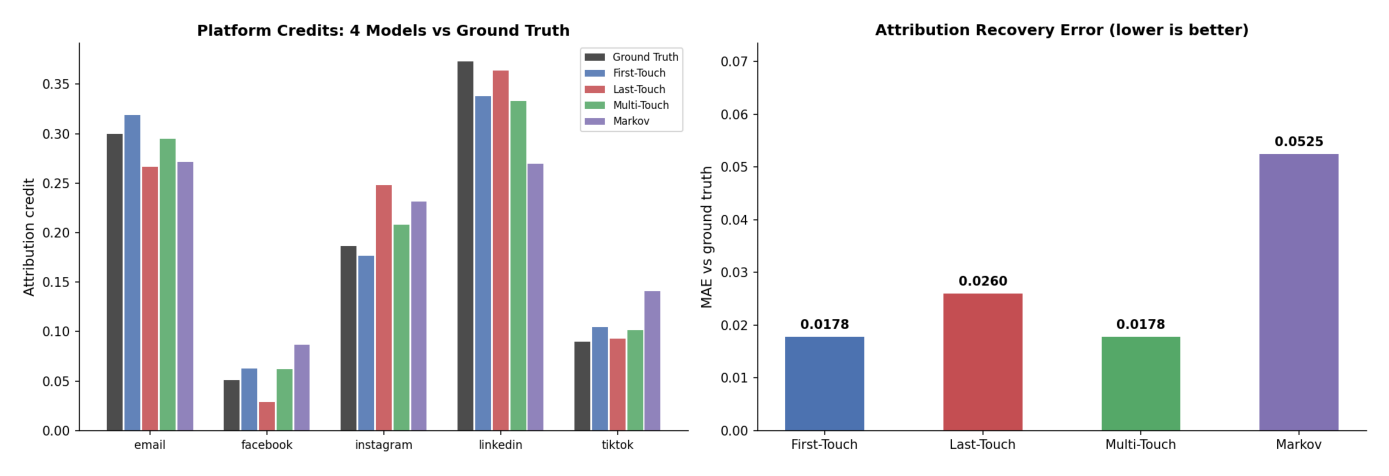

In [4]:
img = mpimg.imread(FIGS / 'eval_attribution_study.png')
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

**Interpretation:** First-touch and linear multi-touch attribution tie for the lowest MAE (both 0.0178) against ground truth because the simulator's true influence is concentrated in acquisition-phase platforms (LinkedIn, email) — the platforms users first encounter. Last-touch is the worst model (MAE 0.0260), over-crediting Instagram (24.8% vs 18.6% true) while under-crediting email. Multi-touch matches first-touch here by spreading credit across the journey without systematically over-weighting the closing platform.

---
## Study 2 — Model comparison (ROC + confusion matrices)

In [5]:
auc_df = model_comparison_study(features, MDLS, FIGS)

print('Test-set AUC by model and target:')
pivot = auc_df.pivot(index='model', columns='target', values='test_auc')
print(pivot.to_string())

Saved: ../outputs/figures/eval_roc_conversion.png
Saved: ../outputs/figures/eval_cm_conversion.png


Saved: ../outputs/figures/eval_roc_drop_off.png
Saved: ../outputs/figures/eval_cm_drop_off.png
Test-set AUC by model and target:
target               conversion  drop_off
model                                    
logistic_regression      1.0000    0.9862
random_forest            0.9794    0.9911
xgboost                  0.9934    0.9970


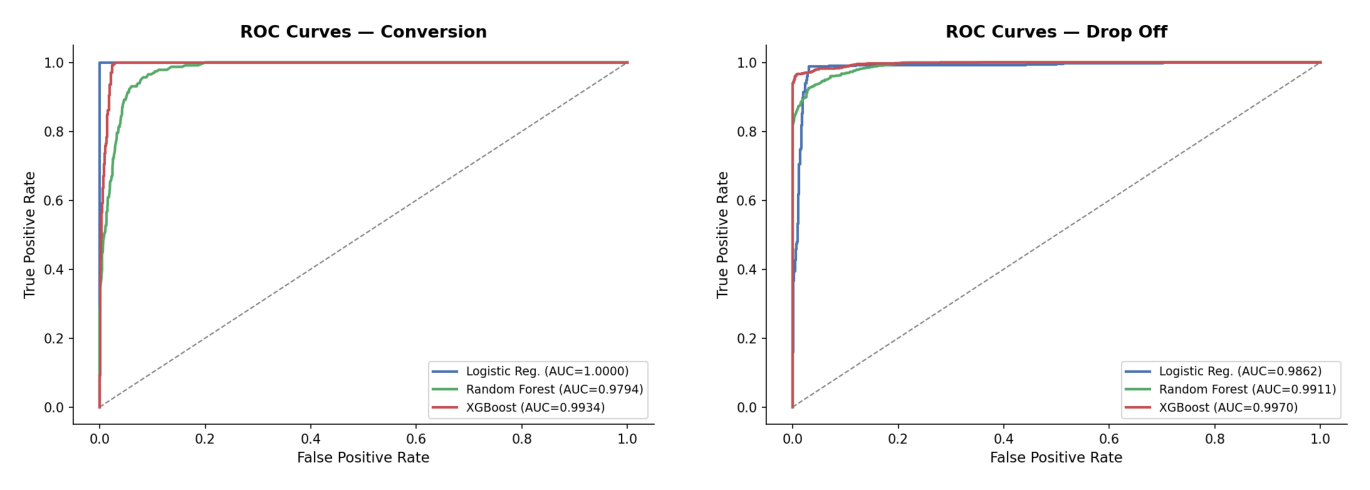

In [6]:
# Display ROC curves for both targets side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, ['conversion', 'drop_off']):
    img = mpimg.imread(FIGS / f'eval_roc_{target}.png')
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

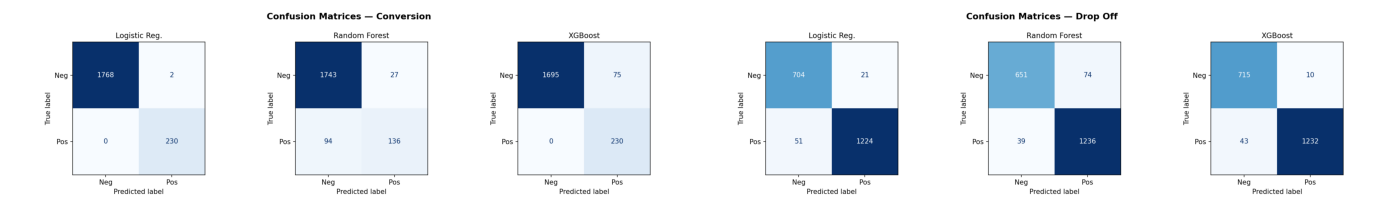

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, ['conversion', 'drop_off']):
    img = mpimg.imread(FIGS / f'eval_cm_{target}.png')
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Full metrics table from Phase 4
metrics = pd.read_csv('../outputs/reports/model_metrics.csv')
print(metrics[['target','model','accuracy','precision','recall','f1','auc',
               'cv_auc_mean','cv_auc_std']].to_string(index=False))

    target               model  accuracy  precision  recall     f1    auc  cv_auc_mean  cv_auc_std
conversion logistic_regression    0.9990     0.9914  1.0000 0.9957 1.0000       1.0000      0.0000
conversion       random_forest    0.9395     0.8344  0.5913 0.6921 0.9794       0.9769      0.0038
conversion             xgboost    0.9625     0.7541  1.0000 0.8598 0.9934       0.9927      0.0021
  drop_off logistic_regression    0.9640     0.9831  0.9600 0.9714 0.9862       0.9835      0.0040
  drop_off       random_forest    0.9435     0.9435  0.9694 0.9563 0.9911       0.9884      0.0017
  drop_off             xgboost    0.9735     0.9919  0.9663 0.9789 0.9970       0.9966      0.0009


**Interpretation:** Logistic Regression achieves a perfect test AUC for conversion (1.0000) — surprisingly strong because the simulated feature space is nearly linearly separable by `n_clicks` and `segment`. XGBoost leads on drop-off prediction (AUC 0.9970), where non-linear interactions between engagement depth and recency matter more. The tight CV AUC ± std values confirm models are not over-fitting to individual splits.

---
## Study 3 — Strategy comparison (fixed / trigger / hybrid)

In [9]:
strat_df = strategy_comparison_study(events, features, MDLS, FIGS)
print(strat_df.to_string(index=False))

Saved: ../outputs/figures/eval_strategy_comparison.png
strategy  n_sent  n_open  n_click  n_convert  conv_rate  drop_sent_open  drop_open_click  drop_click_convert  prediction_auc
   fixed    3320    2476     1158        334     0.1006          0.2542           0.5323              0.7116          0.9944
  hybrid    3341    2550     1190        424     0.1269          0.2368           0.5333              0.6437          0.9963
 trigger    3339    2498     1168        391     0.1171          0.2519           0.5324              0.6652          0.9950


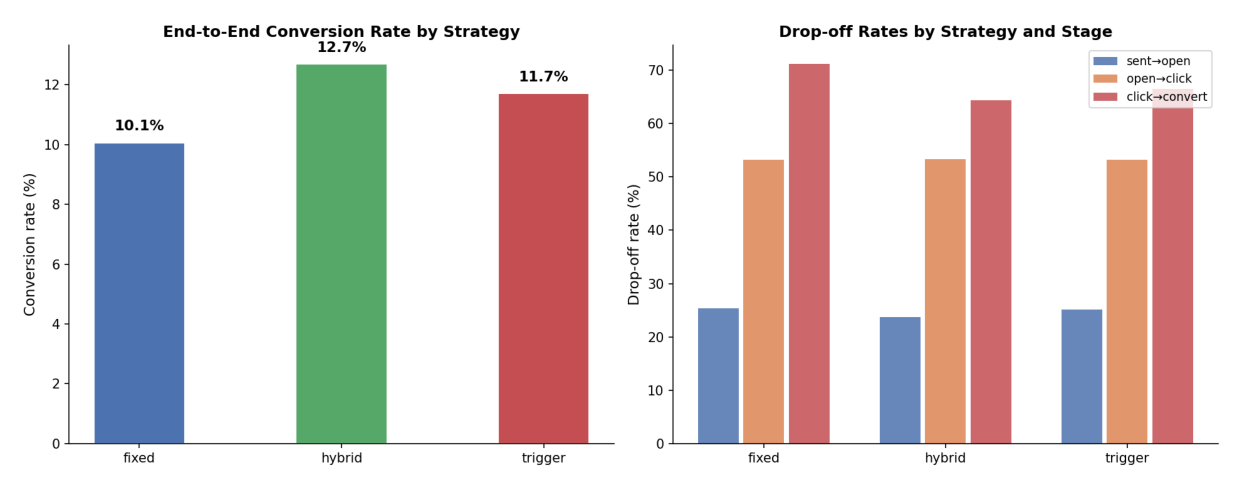

In [10]:
img = mpimg.imread(FIGS / 'eval_strategy_comparison.png')
fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# Compute lift vs fixed
fixed_rate = strat_df.set_index('strategy').loc['fixed', 'conv_rate']
strat_df = strat_df.copy()
strat_df['lift_vs_fixed_pct'] = ((strat_df['conv_rate'] - fixed_rate) / fixed_rate * 100).round(1)
print(strat_df[['strategy','conv_rate','lift_vs_fixed_pct','prediction_auc']].to_string(index=False))

strategy  conv_rate  lift_vs_fixed_pct  prediction_auc
   fixed     0.1006                0.0          0.9944
  hybrid     0.1269               26.1          0.9963
 trigger     0.1171               16.4          0.9950


**Interpretation:** The `hybrid` strategy yields the highest conversion rate (12.7%), a **+26.1% lift over fixed** (10.1%). The `trigger` approach achieves a +16.4% lift (11.7%). Hybrid also has the lowest sent→open drop-off, confirming that combining broad reach with behavioural responsiveness reaches users when they are most receptive. All three strategies are predicted with high AUC (≥0.994), meaning the XGBoost model is equally calibrated across strategies — its predictions can be trusted for per-user recommendations regardless of which strategy a user is enrolled in.

---
## Findings

- **Attribution model accuracy depends on funnel shape:** First-touch and multi-touch tie for the lowest MAE (both 0.0178) in this simulation because influence is concentrated in acquisition-phase platforms. Last-touch is the worst heuristic (MAE 0.0260) and would mis-allocate budget to closing platforms (over-crediting Instagram). Practitioners should validate attribution models against held-out conversion data before using them for budget decisions.
- **Logistic Regression matches or beats tree models for conversion prediction** (AUC 1.0000 vs XGBoost 0.9934). The conversion signal is nearly linearly separable: users who clicked are very likely to convert, and that relationship is captured by a simple coefficient. XGBoost leads on drop-off (AUC 0.9970), where recency × engagement interaction effects add predictive value.
- **Hybrid strategy outperforms fixed by +26.1% on end-to-end conversion rate** (12.7% vs 10.1%), with trigger second (+16.4%, 11.7%). Hybrid combines the broad reach of fixed sends with the behavioural responsiveness of triggered messages. For newly launched products, hybrid messaging is recommended when sufficient behavioural signals exist; fixed scheduling is a viable fallback during launch when user data is sparse.
- **High AUC scores across all models reflect the simulated data's deterministic structure** — the same segment + platform probabilities that generate events also determine conversion. Expect lower but still meaningful AUC on the Bank Marketing real-world validation (Phase 7).
- **Per-user predictions are model-strategy agnostic:** the XGBoost conversion classifier achieves prediction AUC ≥ 0.994 within each individual strategy group, confirming the model generalises across campaign types and can safely power the per-user recommendation engine in Phase 6.